In [25]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [26]:
df =pd.read_csv('datasets/Admission_Predict_Ver1.1.csv')

In [27]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [28]:
df.shape

(500, 9)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [30]:
df.drop(columns=['Serial No.'],inplace=True)

In [36]:
X=df.drop(columns='Chance of Admit ')
y=df['Chance of Admit ']

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [50]:
from sklearn.preprocessing import MinMaxScaler
# minmax is used when upper and lower bound are known
scaler= MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
X_train.shape

(400, 7)

In [52]:
X_test.shape

(100, 7)

In [53]:
y_train.shape

(400,)

In [54]:
y_test.shape

(100,)

In [83]:
# building ann

In [93]:
model = Sequential()

In [94]:
model.add(Dense(7,activation = 'relu',input_dim=7))
model.add(Dense(7,activation = 'relu'))
model.add(Dense(1,activation='linear')) #activation of output layer in regression case has to be linear

C:\Users\Kartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 7)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 7)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [96]:
model.compile(loss='mean_squared_error',optimizer='Adam')

In [97]:
history=model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0903 - val_loss: 0.0738
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0688 - val_loss: 0.0591
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0601 - val_loss: 0.0506
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0517 - val_loss: 0.0437
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0443 - val_loss: 0.0380
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0380 - val_loss: 0.0327
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0322 - val_loss: 0.0281
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0272 - val_loss: 0.0235
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0230 - val_loss: 0.0202
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0192 - val_loss: 0.0172


In [98]:
y_pred= model.predict(X_test_scaled)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


array([[1.1084896 ],
       [0.9479917 ],
       [0.85600376],
       [0.74810326],
       [0.8832344 ],
       [0.9323777 ],
       [0.3331807 ],
       [0.7321271 ],
       [0.4666305 ],
       [0.49734274],
       [0.55541027],
       [0.5844313 ],
       [0.72810686],
       [0.60873437],
       [0.45430666],
       [0.93351114],
       [1.027399  ],
       [0.51982415],
       [0.7125356 ],
       [0.63452995],
       [0.7716284 ],
       [0.9823773 ],
       [0.93111193],
       [0.97548664],
       [0.5630853 ],
       [0.5461476 ],
       [0.9531702 ],
       [0.8351979 ],
       [0.93989563],
       [0.48889428],
       [0.9575064 ],
       [0.48097014],
       [0.21923694],
       [0.8346721 ],
       [0.4601651 ],
       [0.4770126 ],
       [1.0747297 ],
       [0.4853863 ],
       [0.20982017],
       [0.37798825],
       [0.6115775 ],
       [1.0933161 ],
       [0.580902  ],
       [0.7065345 ],
       [1.0888884 ],
       [1.0647031 ],
       [0.83739114],
       [0.928

In [99]:
from sklearn.metrics import r2_score

In [100]:
r2_score(y_test,y_pred)

0.22217274582598545

In [101]:
# plotting training and validation loss

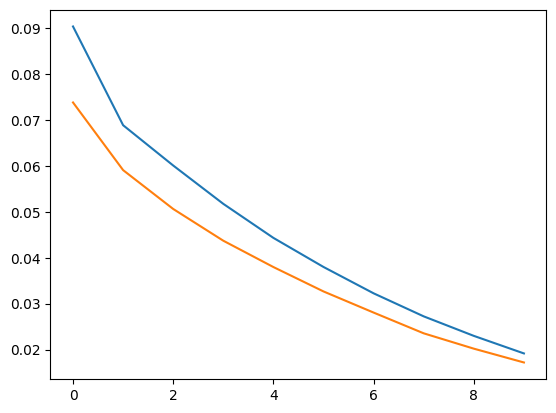

In [102]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])